# MRI Diffusion Reconstruction

In [1]:

import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn


In [2]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


In [3]:

def fft2(x):
    return torch.fft.fft2(x)

def ifft2(k):
    return torch.fft.ifft2(k).real

In [4]:

def create_mask_from_T(shape, T):
    sampling_ratio = 1 - T

    total = shape[0] * shape[1]
    num_samples = int(total * sampling_ratio.item())

    mask = torch.zeros(total, device=device)
    idx = torch.randperm(total)[:num_samples]
    mask[idx] = 1

    return mask.reshape(shape)


In [5]:

def forward_diffusion(x, T):
    noise = torch.randn_like(x)

    alpha = (1 - T).view(1,1)
    x_t = torch.sqrt(alpha) * x + torch.sqrt(1 - alpha) * noise

    return x_t, noise

In [6]:

def degradation_pipeline(x, T):
    mask = create_mask_from_T(x.shape, T)

    k = fft2(x)
    k_sub = k * mask

    x_alias = ifft2(k_sub)

    x_t, noise = forward_diffusion(x_alias, T)

    return x_t, noise, mask, k_sub


In [7]:
import torch.nn.functional as F

class MRIDataset(Dataset):
    
    def __init__(self, root_dir, target_size=256):
        self.slices = []
        self.target_size = target_size

        for f in os.listdir(root_dir):
            if f.endswith(".mat"):
                data = loadmat(os.path.join(root_dir, f))
                x = data["x"]

                for k in range(x.shape[2]):
                    img = x[:, :, k]

                    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
                    
                    self.slices.append(img.astype(np.float32))

    def __len__(self):
        return len(self.slices)

    def __getitem__(self, idx):
        x = torch.tensor(self.slices[idx], device=device)

        x = x.unsqueeze(0).unsqueeze(0)  # (1,1,H,W)
        x = F.interpolate(x, size=(self.target_size, self.target_size), mode='bilinear')
        x = x.squeeze(0).squeeze(0)  # volta pra (H,W)

        T = torch.rand(1, device=device) * 0.9 + 0.05

        x_t, noise, mask, k_sub = degradation_pipeline(x, T)

        return x_t, noise, x, mask, k_sub, T

In [8]:

dataset_path = "/kaggle/input/datasets/semnickcharlie/brain-dataset1/birn_database_converted_to_matlab"

dataset = MRIDataset(dataset_path)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

In [9]:

class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, 3, padding=1)
        )

    def forward(self, x, t):
        return self.net(x)


In [10]:

model = SimpleUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [11]:

epochs = 5

for epoch in range(epochs):

    total_loss = 0

    for x_t, noise, x, mask, k_sub, T in loader:
        
        x_t = x_t.unsqueeze(1)   # (B,1,H,W)
        noise = noise.unsqueeze(1)

        optimizer.zero_grad()

        pred_noise = model(x_t, T)

        loss = ((pred_noise - noise)**2).mean()

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}: Loss = {total_loss/len(loader)}")

Epoch 0: Loss = 0.11305668919685469
Epoch 1: Loss = 0.03132535484966947
Epoch 2: Loss = 0.027223088448654065
Epoch 3: Loss = 0.02529730375633756
Epoch 4: Loss = 0.024178960396727518


In [12]:

os.makedirs("/kaggle/working/checkpoints", exist_ok=True)

torch.save(model.state_dict(), "/kaggle/working/checkpoints/model.pth")

In [13]:

def data_consistency(x, k_obs, mask):
    k = fft2(x.squeeze(0))
    k = mask * k_obs + (1 - mask) * k
    return ifft2(k).unsqueeze(0)


In [14]:

def reconstruct(model, k_obs, mask):

    x = torch.randn((1, k_obs.shape[0], k_obs.shape[1]), device=device)
    x = x.unsqueeze(0)  # (1,1,H,W)

    for t in np.linspace(1.0, 0.01, 50):

        T = torch.tensor([t], device=device)

        pred_noise = model(x, T)
        x = x - 0.1 * pred_noise

        x = data_consistency(x, k_obs, mask)

    return x


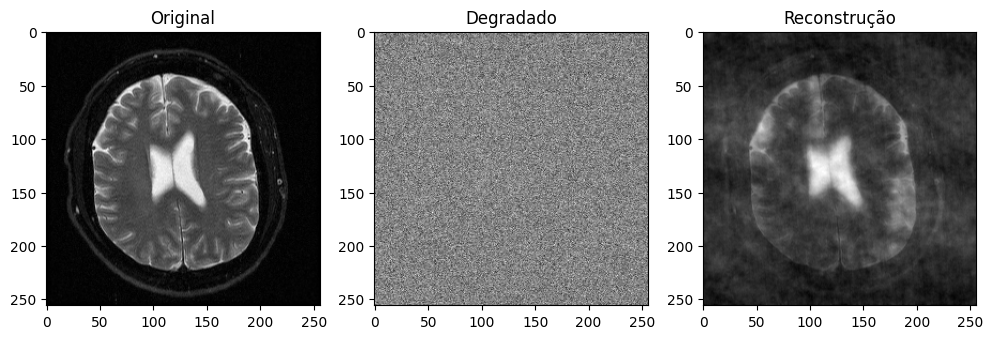

In [15]:

x_t, noise, x, mask, k_sub, T = dataset[10]

recon = reconstruct(model, k_sub, mask)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(x.cpu(), cmap="gray")

plt.subplot(1,3,2)
plt.title("Degradado")
plt.imshow(x_t.cpu(), cmap="gray")

plt.subplot(1,3,3)
plt.title("Reconstrução")
plt.imshow(recon.squeeze().detach().cpu(), cmap="gray")

plt.show()